In [74]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


import pandas as pd

# Load dataset
df = pd.read_csv('cleaned_online_retail.csv')

# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create total sales
df['TotalSales'] = df['UnitPrice'] * df['Quantity']

# Convert to hourly time series
hourly_df = df.set_index('InvoiceDate')['TotalSales'].resample('h').sum().reset_index()

# Handle extreme values (same as your friend did)
ceiling_value = hourly_df['TotalSales'].quantile(0.95)
hourly_df['CappedSales'] = np.where(
    hourly_df['TotalSales'] > ceiling_value,
    ceiling_value,
    hourly_df['TotalSales']
)

# Final dataframe for LSTM
ml_df = hourly_df[['InvoiceDate', 'CappedSales']].copy()
ml_df.columns = ['ds', 'y']
ml_df.set_index('ds', inplace=True)

ml_df['hour'] = ml_df.index.hour
ml_df['dayofweek'] = ml_df.index.dayofweek
ml_df['month'] = ml_df.index.month

# 🔥 LAG FEATURES
ml_df['lag_1'] = ml_df['y'].shift(1)
ml_df['lag_24'] = ml_df['y'].shift(24)
ml_df['lag_168'] = ml_df['y'].shift(168)

# 🔥 ROLLING FEATURE
ml_df['rolling_mean_24'] = ml_df['y'].rolling(24).mean()

# Remove NaN values created by lagging
ml_df.dropna(inplace=True)

# Use hourly data
features = ml_df[['y', 'hour', 'dayofweek', 'month',
                  'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

In [75]:
def create_sequences(data, seq_length=336):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length=336)

In [76]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [77]:
model = Sequential()



model.add(Bidirectional(LSTM(128, return_sequences=True),
                        input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mae')

C:\Users\Divyansh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

In [79]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 167s 758ms/step - loss: 0.1483 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 161s 759ms/step - loss: 0.0877 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 200s 750ms/step - loss: 0.0812 - val_loss: 0.1046 - learning_rate: 0.0010
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 116s 545ms/step - loss: 0.0786 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 116s 546ms/step - loss: 0.0747 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 117s 554ms/step - loss: 0.0761 - val_loss: 0.1152 - learning_rate: 0.0010
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 120s 564ms/step - loss: 0.0739 - val_loss: 0.1100 - learning_rate: 0.0010
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 117s 553ms/step - loss: 0.0752 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 9/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 115s 542ms/step - loss: 0.0739 - val_loss: 0.093

In [80]:
print("X_train shape:", X_train.shape)

X_train shape: (6762, 336, 8)


In [81]:
predictions = model.predict(X_test)

53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step


In [89]:
# Get correct number of features
num_features = scaled_data.shape[1]   # this will be 8

# Create dummy arrays with correct shape
pred_dummy = np.zeros((len(predictions), num_features))
pred_dummy[:, 0] = predictions.flatten()

y_dummy = np.zeros((len(y_test), num_features))
y_dummy[:, 0] = y_test.flatten()

# Inverse transform
predictions = scaler.inverse_transform(pred_dummy)[:, 0]
y_test_actual = scaler.inverse_transform(y_dummy)[:, 0]

In [90]:
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 383.50895265953966
LSTM RMSE: 839.4357597362214


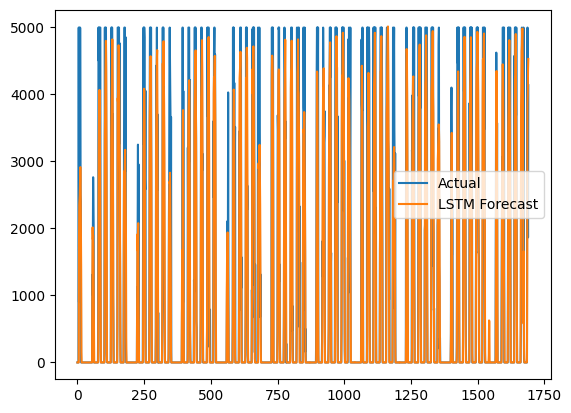

In [91]:
plt.plot(y_test_actual, label='Actual')
plt.plot(predictions, label='LSTM Forecast')
plt.legend()
plt.show()